In [1]:
from utils.generic_utils import load_all_games_csv, get_teams
from elos.elo_tracker import EloTracker
import numpy as np
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import poisson

# Margin of Victory Analysis

This notebook will analyze the relationship between the margin of victory for a team vs. the difference in Elo ratings. We hope to be able to use the difference to predict the margin of victory.

## Get all Games

In [ ]:
all_games = load_all_games_csv('../data/gameinfo_cleaned.csv', preprocess=True)
#all_games = all_games[(all_games['season'] >= 1990) & (all_games['season'] < 2000)]
all_games.head()

/Users/lancehendricks/Documents/College Coding/ML/Elo Ratings/analysis/src/utils/generic_utils.py:30: DtypeWarning: Columns (10,11,13,17,19,20,21,27,28) have mixed types. Specify dtype option on import or set low_memory=False.
  all_games = pd.read_csv(filename)


,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,homerestdays,visrestdays,homepitcherrgs,vispitcherrgs,hometeamrgs,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct
gid,,,,,,,,,,,,,,,,,,,,,
CIN189804150,CL4,CIN,CIN05,18980415,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
LS3189804150,PIT,LS3,LOU03,18980415,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
SLN189804150,CHN,SLN,STL05,18980415,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
BLN189804160,WSN,BLN,BAL07,18980416,0.0,0:00PM,day,NaN,NaN,False,...,NaN,NaN,39.0,39.0,39.0,39.0,0.0,0.0,NaN,NaN
CIN189804160,CL4,CIN,CIN05,18980416,0.0,0:00PM,day,NaN,NaN,False,...,1.0,1.0,39.0,39.0,65.9,64.9,-26.9,-25.9,1.0,0.0


## Incorporate Elos into df

In [6]:
w = np.array([[ 1.        ],
       [27.1440666 ],
       [ 4.81476328],
       [-0.30523283],
       [ 1.58004319]])

In [8]:
et = EloTracker()
et.add_history(all_games, add_elos_to_df=True)

## Plot difference vs margin

In [9]:
all_games['winningelodiff'] = all_games.apply(lambda row: row['homeelobefore'] - row['viselobefore'] if row['homewon'] else row['viselobefore'] - row['homeelobefore'], axis=1)
all_games.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct,homeelobefore,viselobefore,homeeloafter,viseloafter,winningelodiff
gid,,,,,,,,,,,,,,,,,,,,,
CIN189804150,CL4,CIN,CIN05,18980415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1501.500000,1498.500000,0.0
LS3189804150,PIT,LS3,LOU03,18980415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1501.500000,1498.500000,0.0
SLN189804150,CHN,SLN,STL05,18980415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1498.500000,1501.500000,0.0
BLN189804160,WSN,BLN,BAL07,18980416,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1501.500000,1498.500000,0.0
CIN189804160,CL4,CIN,CIN05,18980416,0.0,0:00PM,day,NaN,NaN,False,...,64.9,-26.9,-25.9,1.0,0.0,1501.5,1498.5,1499.987048,1500.012952,-3.0


Text(0, 0.5, 'Margin of Victory')

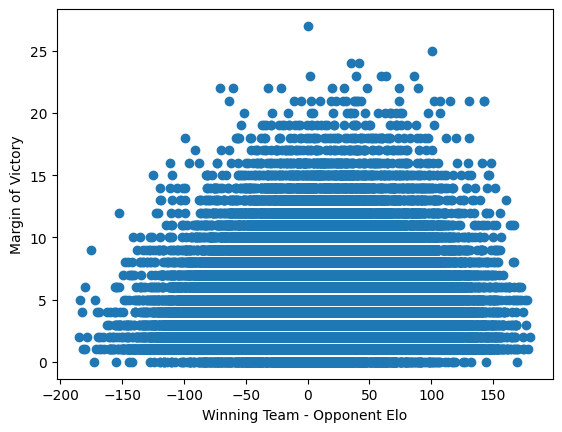

In [10]:
plt.scatter(all_games['winningelodiff'], all_games['marginofvictory']**2)
plt.xlabel('Winning Team - Opponent Elo')
plt.ylabel('Margin of Victory')


### With line fitted

Coefficients: [0.00129341]
Intercept: 1.7023867570654347


Text(0, 0.5, 'Margin of Victory')

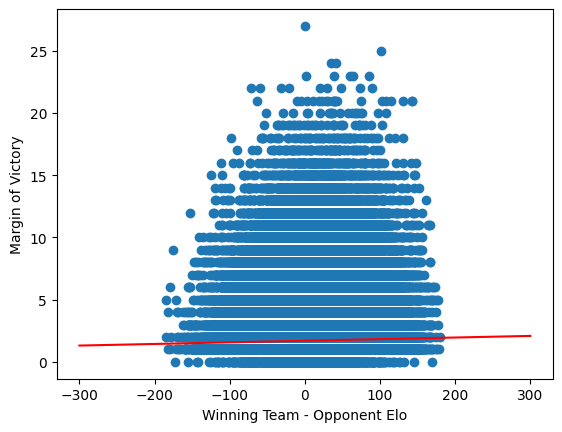

In [11]:
lr = LinearRegression()

lr.fit(all_games['winningelodiff'].to_numpy().reshape(-1,1), all_games['marginofvictory'].to_numpy().reshape(-1,1))

coefs = lr.coef_[0]
intercept = lr.intercept_[0]
print("Coefficients:",coefs)
print("Intercept:",intercept)
xp = np.linspace(-300,300).reshape(-1,1)
yp = lr.predict(xp)

plt.plot(xp,yp,color='red')
plt.scatter(all_games['winningelodiff'], all_games['marginofvictory']**2)
plt.xlabel('Winning Team - Opponent Elo')
plt.ylabel('Margin of Victory')


## Plot Margin counts for a given difference

In [12]:
difference = 0
all_games_elos_difference = all_games[all_games['winningelodiff'] == difference]
all_games_elos_difference.head()

,visteam,hometeam,site,date,number,starttime,daynight,innings,tiebreaker,usedh,...,visteamrgs,homepitcherminusteamrgs,vispitcherminusteamrgs,homelastkwinpct,vislastkwinpct,homeelobefore,viselobefore,homeeloafter,viseloafter,winningelodiff
gid,,,,,,,,,,,,,,,,,,,,,
CIN189804150,CL4,CIN,CIN05,18980415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1501.5,1498.5,0.0
LS3189804150,PIT,LS3,LOU03,18980415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1501.5,1498.5,0.0
SLN189804150,CHN,SLN,STL05,18980415,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1498.5,1501.5,0.0
BLN189804160,WSN,BLN,BAL07,18980416,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1501.5,1498.5,0.0
NY1189804160,BSN,NY1,NYC10,18980416,0.0,0:00PM,day,NaN,NaN,False,...,39.0,0.0,0.0,NaN,NaN,1500.0,1500.0,1498.5,1501.5,0.0


Text(0, 0.5, 'Games')

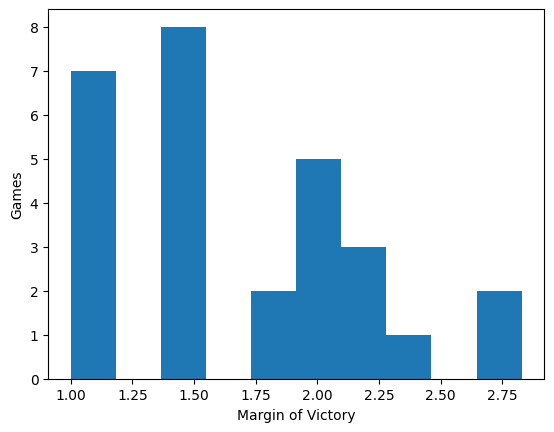

In [13]:
plt.hist(all_games_elos_difference['marginofvictory'])
plt.xlabel('Margin of Victory')
plt.ylabel('Games')

In [14]:
all_games_elos_difference['marginofvictory'].mean()

1.6574886509005657

(array([7.06700000e-01, 4.97314286e-01, 1.75785714e-01, 0.00000000e+00,
        3.98714286e-02, 7.70000000e-03, 0.00000000e+00, 1.05714286e-03,
        1.28571429e-04, 1.42857143e-05]),
 array([1. , 1.7, 2.4, 3.1, 3.8, 4.5, 5.2, 5.9, 6.6, 7.3, 8. ]),
 <BarContainer object of 10 artists>)

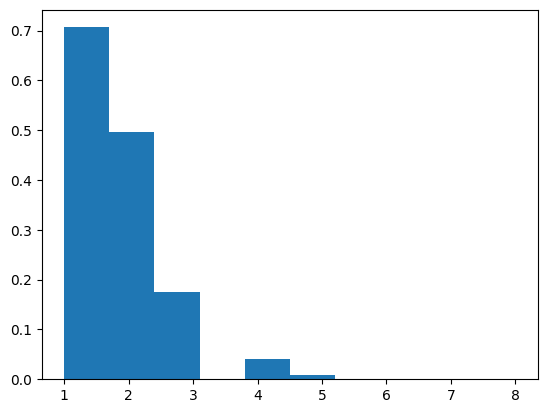

In [15]:
samples = []

for _ in range(100000):
    samples.append(poisson.rvs(mu=0.7, loc=1))
    
plt.hist(samples,density=True)